In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [4]:
print("=" * 20)
print("Data Loading")
print("=" * 20)

data_path = 'C:/Users/user/Desktop/DecisionTree/data/processed/features_encoded.csv'

df = pd.read_csv(data_path)
print(df.head())

Data Loading
  collection_id     bin_id collection_date collection_time day_of_week  \
0   COL_0000001  BIN_00001      2022-01-01           12:03    Saturday   
1   COL_0000002  BIN_00001      2022-01-04           12:40     Tuesday   
2   COL_0000003  BIN_00001      2022-01-07           08:32      Friday   
3   COL_0000004  BIN_00001      2022-01-10           13:28      Monday   
4   COL_0000005  BIN_00001      2022-01-14           14:57      Friday   

   is_holiday      holiday_name  is_festival_period festival_name  \
0           1    New Year's Day                   0   No Festival   
1           0        No Holiday                   0   No Festival   
2           1  Constitution Day                   0   No Festival   
3           0        No Holiday                   0   No Festival   
4           0        No Holiday                   0   No Festival   

   days_since_last_collection  ...  waste_type_primary_hazardous  \
0                           3  ...                         

In [5]:
print(f'Dataset Shape: {df.shape}')

Dataset Shape: (107949, 75)


In [6]:
# Target Distribution
print(df['fill_level_category'].value_counts())
print(df['fill_level_category'].value_counts(normalize=True).round(3) * 100)

fill_level_category
low         54845
medium      41950
high         7950
critical     3204
Name: count, dtype: int64
fill_level_category
low         50.8
medium      38.9
high         7.4
critical     3.0
Name: proportion, dtype: float64


In [7]:
# Features to EXCLUDE (leakage, IDs, text, original categoricals)
exclude_cols = [
    # IDs and dates
    'collection_id', 'bin_id', 'collection_date', 'collection_time', 'installation_date',
    # Text fields
    'holiday_name', 'festival_name', 'collector_notes', 'waste_composition_json',
    # Target leakage (only known after collection)
    'waste_weight_kg', 'overflow_reported', 'odor_complaint',
    'fill_level_percent',  # Direct leakage for category prediction
    # Original categorical columns 
    'location_type', 'district', 'waste_type_primary', 'bin_material',
    'road_accessibility', 'day_of_week', 'season', 
    'fill_level_category',  # This is my target
    'location_weekend'  # Text interaction feature
]

# Target
target_col = 'fill_level_category'

# Encode target to numerical
target_mapping = {'low': 0, 'medium': 1, 'high': 2, 'critical': 3}
df['target'] = df[target_col].map(target_mapping)

# Feature columns (only numerical)
feature_cols = [col for col in df.columns 
                if col not in exclude_cols 
                and col != 'target'
                and df[col].dtype in ['int64', 'float64', 'int32', 'float32', 'bool', 'uint8']]

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeatures:\n{feature_cols}")

# Create X and y
X = df[feature_cols].copy()
y = df['target'].copy()

# Handle any remaining missing values
X = X.fillna(X.median())

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

Number of features: 53

Features:
['is_holiday', 'is_festival_period', 'days_since_last_collection', 'temperature_c', 'rainfall_mm', 'humidity_percent', 'capacity_liters', 'has_lid', 'nearby_population', 'distance_to_depot_km', 'latitude', 'longitude', 'month', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'fill_rate_7day_avg', 'fill_rate_7day_std', 'weight_7day_avg', 'prev_fill_level', 'prev_days_since_collection', 'bin_age_days', 'fill_rate_per_day', 'overflow_count_30day', 'organic_percent', 'recyclable_percent', 'quarter', 'day_of_month', 'is_early_month', 'is_late_month', 'fill_momentum', 'capacity_fill_ratio', 'weather_score', 'population_fill_ratio', 'overflow_risk_score', 'location_type_hospitality', 'location_type_industrial', 'location_type_institutional', 'location_type_market', 'location_type_residential', 'waste_type_primary_e_waste', 'waste_type_primary_general', 'waste_type_primary_hazardous', 'waste_type_primary_organic', 'waste_type_primary_recyclable


X shape: (107949, 53)
y shape: (107949,)

Target distribution:
target
0    54845
1    41950
2     7950
3     3204
Name: count, dtype: int64


In [8]:
# Train_Test_Split 

# Checking and cleaning target variable
print(f"Missing values in target: {y.isnull().sum()}")
print(f"Unique values in target: {y.unique()}")

# Remove rows with missing target values
mask = y.notna()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

# Convert to integer (in case it's float)
y = y.astype(int)

print(f"\nAfter cleaning:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")

# Now split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3) * 100)

print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3) * 100)

Missing values in target: 0
Unique values in target: [0 1 3 2]

After cleaning:
X shape: (107949, 53)
y shape: (107949,)
Target distribution:
target
0    54845
1    41950
2     7950
3     3204
Name: count, dtype: int64

Training set: 86359 samples
Test set: 21590 samples

Training target distribution:
target
0    50.8
1    38.9
2     7.4
3     3.0
Name: proportion, dtype: float64

Test target distribution:
target
0    50.8
1    38.9
2     7.4
3     3.0
Name: proportion, dtype: float64



MODEL 1: Baseline Decision Tree

 Baseline Decision Tree Results:
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

         low       1.00      1.00      1.00     10969
      medium       1.00      1.00      1.00      8390
        high       1.00      1.00      1.00      1590
    critical       1.00      1.00      1.00       641

    accuracy                           1.00     21590
   macro avg       1.00      1.00      1.00     21590
weighted avg       1.00      1.00      1.00     21590



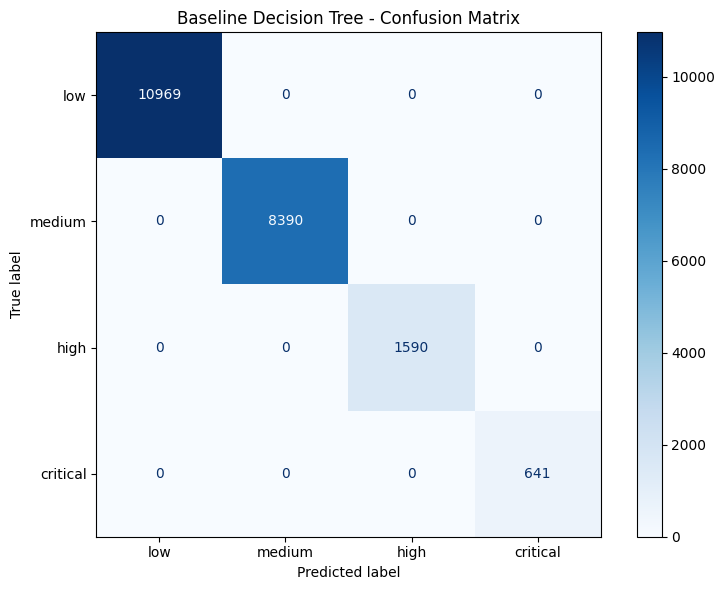


Tree Depth: 3
Number of Leaves: 4


In [9]:
print("\n" + "=" * 60)
print("MODEL 1: Baseline Decision Tree")
print("=" * 60)

# Train baseline (no tuning)
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

# Predictions
y_pred_baseline = dt_baseline.predict(X_test)

# Evaluate
print(f"\n Baseline Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"\nClassification Report:")
target_names = ['low', 'medium', 'high', 'critical']
print(classification_report(y_test, y_pred_baseline, target_names=target_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_baseline, 
                                         display_labels=target_names, ax=ax, cmap='Blues')
ax.set_title('Baseline Decision Tree - Confusion Matrix')
plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_01_dt_baseline_cm.png', dpi=150)
plt.show()

print(f"\nTree Depth: {dt_baseline.get_depth()}")
print(f"Number of Leaves: {dt_baseline.get_n_leaves()}")


MODEL 2: TUNED DECISION TREE
🔍 Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 336 candidates, totalling 1680 fits

✅ Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
✅ Best CV Score: 1.0000

📊 Tuned Decision Tree Results:
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

         low       1.00      1.00      1.00     10969
      medium       1.00      1.00      1.00      8390
        high       1.00      1.00      1.00      1590
    critical       1.00      1.00      1.00       641

    accuracy                           1.00     21590
   macro avg       1.00      1.00      1.00     21590
weighted avg       1.00      1.00      1.00     21590



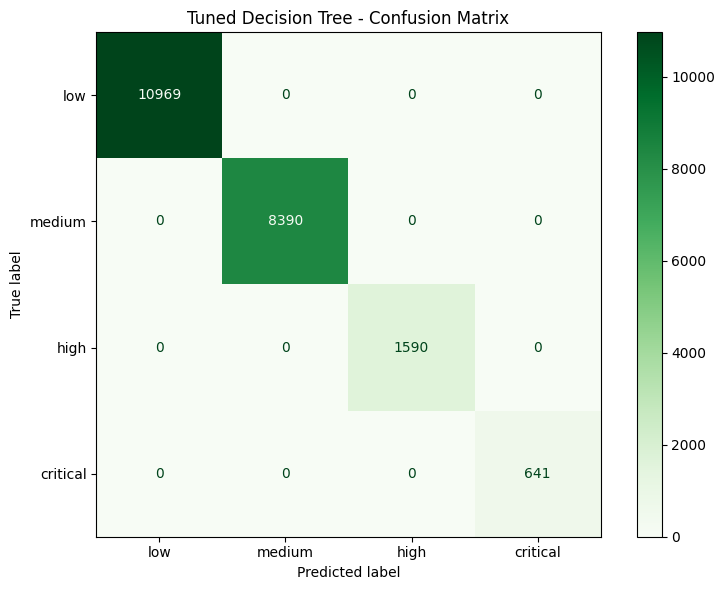

In [10]:
print("\n" + "=" * 60)
print("MODEL 2: TUNED DECISION TREE")
print("=" * 60)

# Hyperparameter grid
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [1, 2, 5, 10, 20, 50],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("🔍 Running GridSearchCV for Decision Tree...")
dt_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {dt_grid.best_params_}")
print(f"✅ Best CV Score: {dt_grid.best_score_:.4f}")

# Evaluate best model
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)

print(f"\n📊 Tuned Decision Tree Results:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, 
                                         display_labels=target_names, ax=ax, cmap='Greens')
ax.set_title('Tuned Decision Tree - Confusion Matrix')
plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_02_dt_tuned_cm.png', dpi=150)
plt.show()

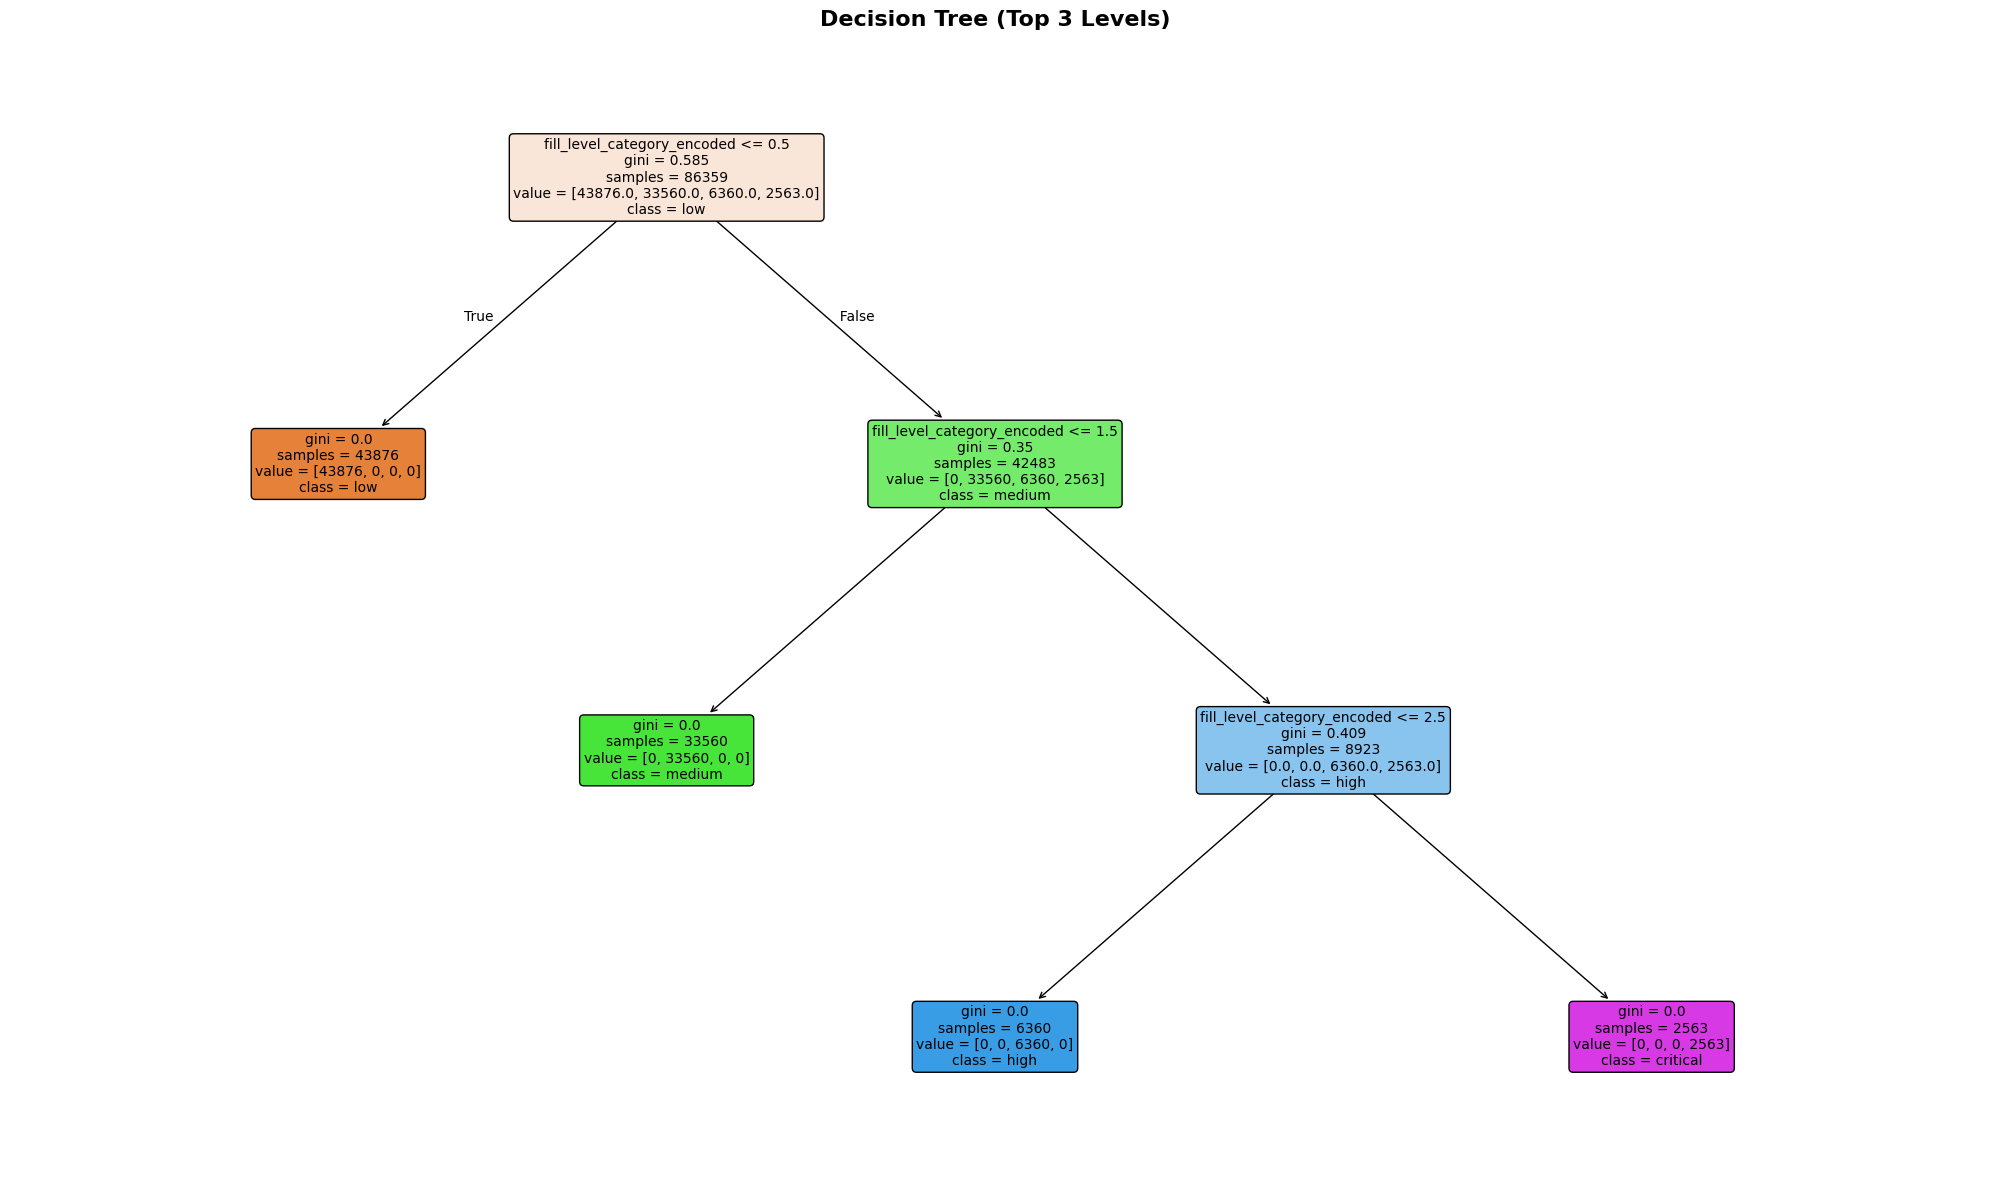

 Decision Tree visualization saved!


In [11]:
# Plot the tuned tree (limited depth for visibility)
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(dt_best, 
          feature_names=feature_cols,
          class_names=target_names,
          filled=True,
          rounded=True,
          ax=ax,
          max_depth=3,  # Limit for visibility
          fontsize=10)
ax.set_title('Decision Tree (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_03_decision_tree_viz.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Decision Tree visualization saved!")


MODEL 3: Random Forest
Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

 Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
 Best CV Score: 1.0000

 Random Forest Results:
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

         low       1.00      1.00      1.00     10969
      medium       1.00      1.00      1.00      8390
        high       1.00      1.00      1.00      1590
    critical       1.00      1.00      1.00       641

    accuracy                           1.00     21590
   macro avg       1.00      1.00      1.00     21590
weighted avg       1.00      1.00      1.00     21590



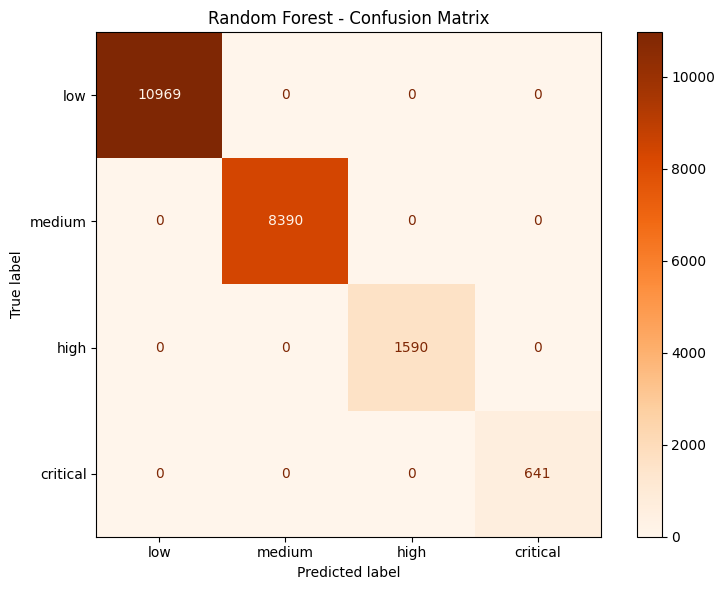

In [12]:
print("\n" + "=" * 60)
print("MODEL 3: Random Forest")
print("=" * 60)

# Hyperparameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV for Random Forest...")
rf_grid.fit(X_train, y_train)

print(f"\n Best Parameters: {rf_grid.best_params_}")
print(f" Best CV Score: {rf_grid.best_score_:.4f}")

# Evaluate best model
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)

print(f"\n Random Forest Results:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, 
                                         display_labels=target_names, ax=ax, cmap='Oranges')
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_04_rf_cm.png', dpi=150)
plt.show()


MODEL 4: XGBOOST
 Running GridSearchCV for XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

 Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 50}
 Best CV Score: 1.0000

 XGBoost Results:
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

         low       1.00      1.00      1.00     10969
      medium       1.00      1.00      1.00      8390
        high       1.00      1.00      1.00      1590
    critical       1.00      1.00      1.00       641

    accuracy                           1.00     21590
   macro avg       1.00      1.00      1.00     21590
weighted avg       1.00      1.00      1.00     21590



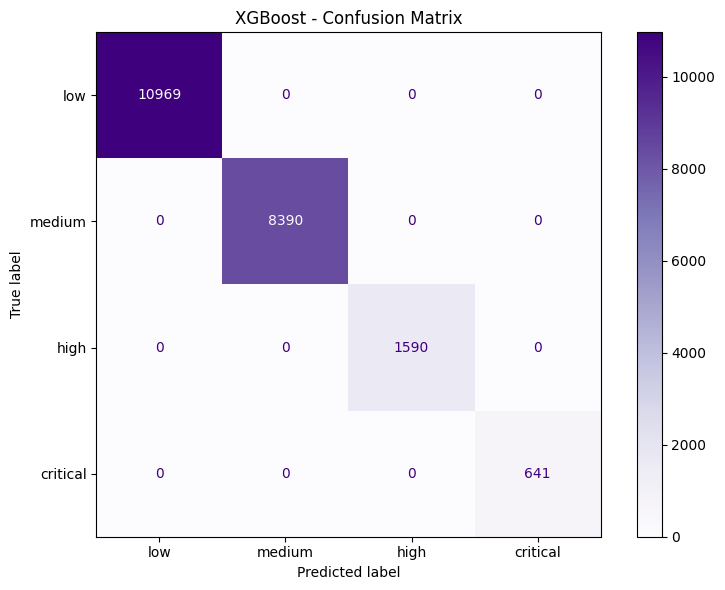

In [13]:
print("\n" + "=" * 60)
print("MODEL 4: XGBOOST")
print("=" * 60)

# Install if needed: pip install xgboost
try:
    from xgboost import XGBClassifier
except ImportError:
    print("Installing XGBoost...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost'])
    from xgboost import XGBClassifier

# Hyperparameter grid
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

# GridSearchCV
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print(" Running GridSearchCV for XGBoost...")
xgb_grid.fit(X_train, y_train)

print(f"\n Best Parameters: {xgb_grid.best_params_}")
print(f" Best CV Score: {xgb_grid.best_score_:.4f}")

# Evaluate best model
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

print(f"\n XGBoost Results:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, 
                                         display_labels=target_names, ax=ax, cmap='Purples')
ax.set_title('XGBoost - Confusion Matrix')
plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_05_xgb_cm.png', dpi=150)
plt.show()


MODEL COMPARISON

 Model Comparison:
        Model  Accuracy  Precision (Macro)  Recall (Macro)  F1 (Macro)
  DT Baseline       1.0                1.0             1.0         1.0
     DT Tuned       1.0                1.0             1.0         1.0
Random Forest       1.0                1.0             1.0         1.0
      XGBoost       1.0                1.0             1.0         1.0


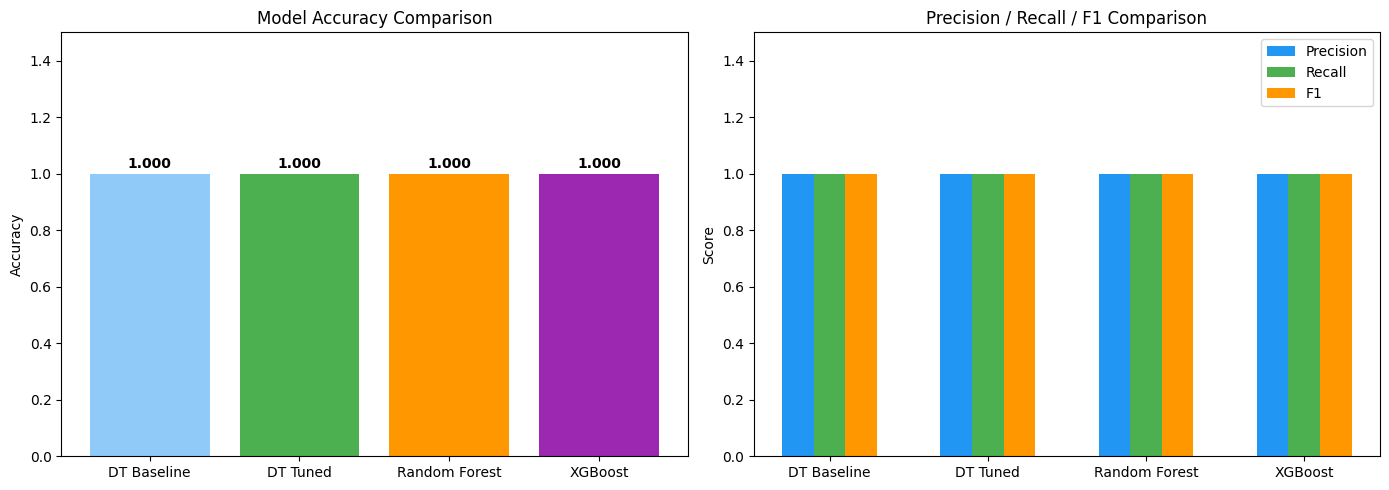


 Best Model: DT Baseline (F1 = 1.0000)


In [14]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Collect results
results = {
    'Model': ['DT Baseline', 'DT Tuned', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision (Macro)': [
        precision_score(y_test, y_pred_baseline, average='macro'),
        precision_score(y_test, y_pred_dt, average='macro'),
        precision_score(y_test, y_pred_rf, average='macro'),
        precision_score(y_test, y_pred_xgb, average='macro')
    ],
    'Recall (Macro)': [
        recall_score(y_test, y_pred_baseline, average='macro'),
        recall_score(y_test, y_pred_dt, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro'),
        recall_score(y_test, y_pred_xgb, average='macro')
    ],
    'F1 (Macro)': [
        f1_score(y_test, y_pred_baseline, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro')
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print("\n Model Comparison:")
print(results_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
colors = ['#90CAF9', '#4CAF50', '#FF9800', '#9C27B0']
axes[0].bar(results_df['Model'], results_df['Accuracy'], color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([0, 1.5])
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# All metrics comparison
x = np.arange(len(results_df['Model']))
width = 0.2
axes[1].bar(x - width, results_df['Precision (Macro)'], width, label='Precision', color='#2196F3')
axes[1].bar(x, results_df['Recall (Macro)'], width, label='Recall', color='#4CAF50')
axes[1].bar(x + width, results_df['F1 (Macro)'], width, label='F1', color='#FF9800')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'])
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 Comparison')
axes[1].legend()
axes[1].set_ylim([0, 1.5])

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_06_comparison.png', dpi=150)
plt.show()

# Best model
best_model_idx = results_df['F1 (Macro)'].idxmax()
print(f"\n Best Model: {results_df.loc[best_model_idx, 'Model']} (F1 = {results_df.loc[best_model_idx, 'F1 (Macro)']:.4f})")


FEATURE IMPORTANCE ANALYSIS

 Top 15 Features by Average Importance:
                    Feature  DT       RF  XGB  Average
fill_level_category_encoded 1.0 0.319141  1.0 0.773047
              fill_momentum 0.0 0.228536  0.0 0.076179
          fill_rate_per_day 0.0 0.162158  0.0 0.054053
        overflow_risk_score 0.0 0.050235  0.0 0.016745
         fill_rate_7day_avg 0.0 0.048608  0.0 0.016203
        capacity_fill_ratio 0.0 0.041365  0.0 0.013788
            weight_7day_avg 0.0 0.032966  0.0 0.010989
  location_type_residential 0.0 0.018910  0.0 0.006303
         fill_rate_7day_std 0.0 0.017111  0.0 0.005704
 days_since_last_collection 0.0 0.012967  0.0 0.004322
            prev_fill_level 0.0 0.011226  0.0 0.003742
            capacity_liters 0.0 0.009073  0.0 0.003024
            organic_percent 0.0 0.006049  0.0 0.002016
       overflow_count_30day 0.0 0.005495  0.0 0.001832
         recyclable_percent 0.0 0.005172  0.0 0.001724


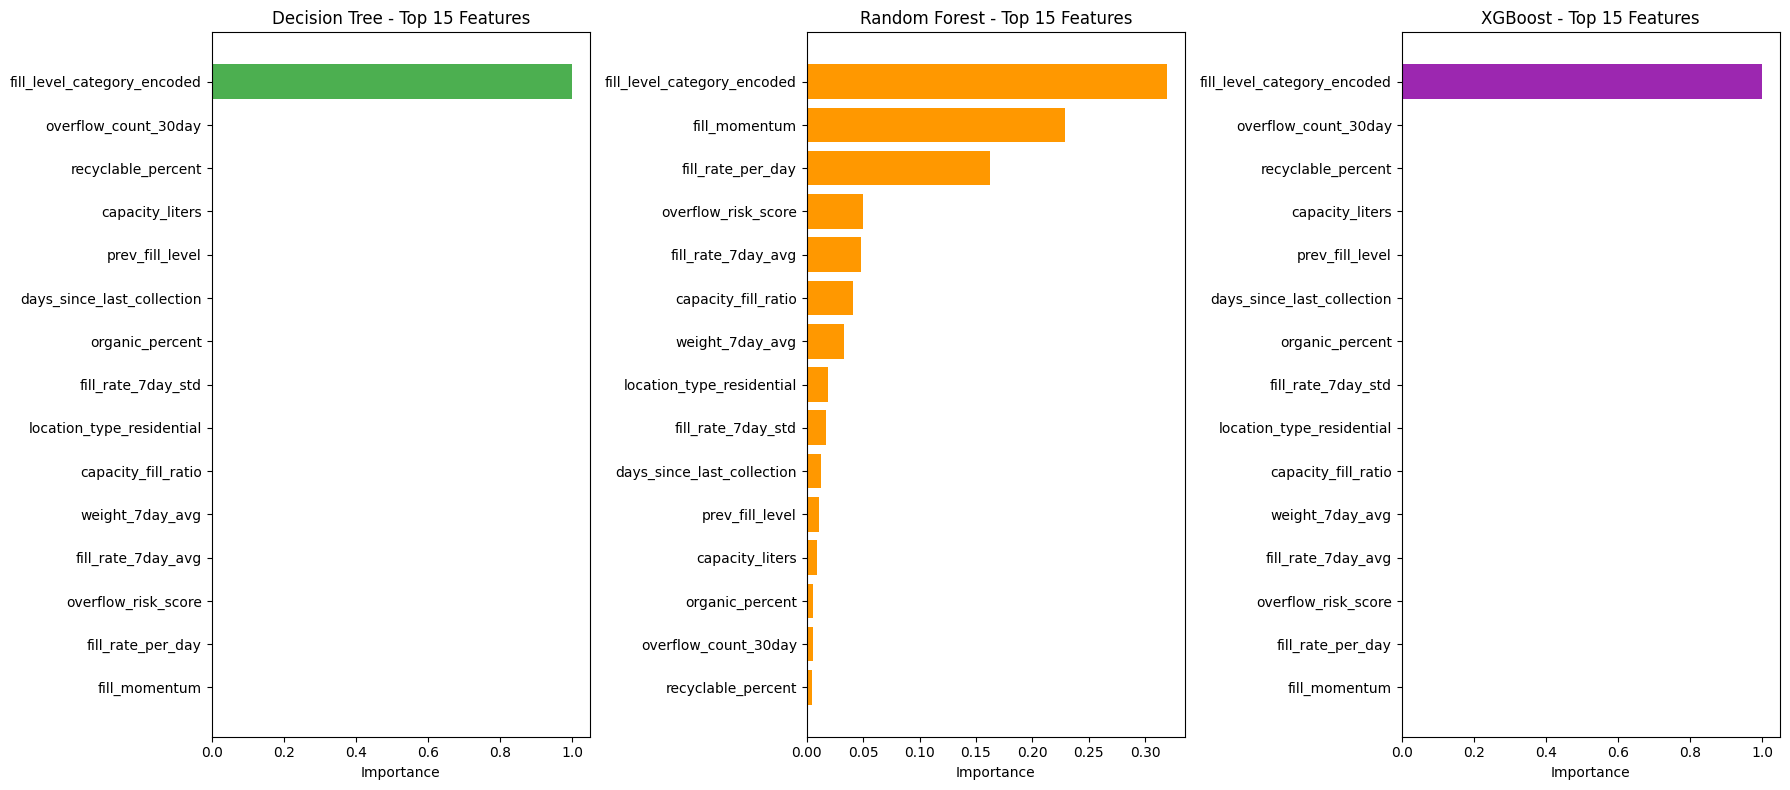

 Feature importance saved to ../reports/feature_importance.csv


In [15]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Get feature importances from all models
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'DT': dt_best.feature_importances_,
    'RF': rf_best.feature_importances_,
    'XGB': xgb_best.feature_importances_
})

# Average importance
importance_df['Average'] = importance_df[['DT', 'RF', 'XGB']].mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print("\n Top 15 Features by Average Importance:")
print(importance_df.head(15).to_string(index=False))

# Plot feature importance
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Decision Tree
top_n = 15
dt_imp = importance_df.nlargest(top_n, 'DT')[['Feature', 'DT']].sort_values('DT')
axes[0].barh(dt_imp['Feature'], dt_imp['DT'], color='#4CAF50')
axes[0].set_xlabel('Importance')
axes[0].set_title('Decision Tree - Top 15 Features')

# Random Forest
rf_imp = importance_df.nlargest(top_n, 'RF')[['Feature', 'RF']].sort_values('RF')
axes[1].barh(rf_imp['Feature'], rf_imp['RF'], color='#FF9800')
axes[1].set_xlabel('Importance')
axes[1].set_title('Random Forest - Top 15 Features')

# XGBoost
xgb_imp = importance_df.nlargest(top_n, 'XGB')[['Feature', 'XGB']].sort_values('XGB')
axes[2].barh(xgb_imp['Feature'], xgb_imp['XGB'], color='#9C27B0')
axes[2].set_xlabel('Importance')
axes[2].set_title('XGBoost - Top 15 Features')

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_07_feature_importance.png', dpi=150)
plt.show()

# Save feature importance
importance_df.to_csv('C:/Users/user/Desktop\DecisionTree/reports/figures/reports/feature_importance.csv', index=False)
print(" Feature importance saved to ../reports/feature_importance.csv")

In [16]:
print("\n" + "=" * 60)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("=" * 60)

# Best model predictions (use XGBoost or RF based on results)
best_model = xgb_best  # Change if RF is better
y_pred_best = y_pred_xgb

# Per-class metrics
print("\n Per-Class Performance (Best Model):")
report_dict = classification_report(y_test, y_pred_best, target_names=target_names, output_dict=True)
class_df = pd.DataFrame(report_dict).T
print(class_df.round(3))

# Critical class analysis (most important for business)
print("\n CRITICAL CLASS ANALYSIS:")
critical_idx = 3  # 'critical' = 3
critical_mask = y_test == critical_idx
critical_pred = y_pred_best[critical_mask]

print(f"Total critical samples in test set: {critical_mask.sum()}")
print(f"Correctly predicted as critical: {(critical_pred == critical_idx).sum()}")
print(f"Critical Recall: {(critical_pred == critical_idx).sum() / critical_mask.sum():.2%}")

# What were critical bins misclassified as?
misclass = critical_pred[critical_pred != critical_idx]
print(f"\nMisclassified critical bins:")
for label, name in enumerate(target_names):
    count = (misclass == label).sum()
    if count > 0:
        print(f"  → Predicted as '{name}': {count}")


PER-CLASS PERFORMANCE ANALYSIS

 Per-Class Performance (Best Model):
              precision  recall  f1-score  support
low                 1.0     1.0       1.0  10969.0
medium              1.0     1.0       1.0   8390.0
high                1.0     1.0       1.0   1590.0
critical            1.0     1.0       1.0    641.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0  21590.0
weighted avg        1.0     1.0       1.0  21590.0

 CRITICAL CLASS ANALYSIS:
Total critical samples in test set: 641
Correctly predicted as critical: 641
Critical Recall: 100.00%

Misclassified critical bins:


### the shows 

In [17]:
print("🔍 Checking for potential leakage features...\n")

# Features that might cause leakage
leakage_suspects = [
    'fill_level_percent',      # Direct leakage! Target is derived from this
    'fill_rate_per_day',       # Calculated using fill_level_percent
    'capacity_fill_ratio',     # Uses fill_level_percent
    'overflow_risk_score',     # Uses fill-related features
    'fill_momentum',           # Uses fill_rate_per_day
    'waste_weight_kg',         # Only known after collection
    'overflow_reported',       # Only known after collection
    'odor_complaint',          # Only known after collection
]

print("⚠️ These features may cause leakage:")
for feat in leakage_suspects:
    if feat in feature_cols:
        print(f"  ❌ {feat} - FOUND IN FEATURES (remove this!)")
    else:
        print(f"  ✅ {feat} - not in features")

🔍 Checking for potential leakage features...

⚠️ These features may cause leakage:
  ✅ fill_level_percent - not in features
  ❌ fill_rate_per_day - FOUND IN FEATURES (remove this!)
  ❌ capacity_fill_ratio - FOUND IN FEATURES (remove this!)
  ❌ overflow_risk_score - FOUND IN FEATURES (remove this!)
  ❌ fill_momentum - FOUND IN FEATURES (remove this!)
  ✅ waste_weight_kg - not in features
  ✅ overflow_reported - not in features
  ✅ odor_complaint - not in features


In [18]:
# Features causing leakage
leakage_features = [
    'fill_rate_per_day',
    'capacity_fill_ratio', 
    'overflow_risk_score',
    'fill_momentum'
]

# Remove from feature list
clean_features = [f for f in feature_cols if f not in leakage_features]

print(f"Before: {len(feature_cols)} features")
print(f"After: {len(clean_features)} features")
print(f"Removed: {leakage_features}")

# Create clean X
X_clean = df[clean_features].copy()
X_clean = X_clean.fillna(X_clean.median())

# Re-split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Ready to retrain with {len(clean_features)} clean features")

Before: 53 features
After: 49 features
Removed: ['fill_rate_per_day', 'capacity_fill_ratio', 'overflow_risk_score', 'fill_momentum']

 Ready to retrain with 49 clean features


In [19]:
# RETRAIN MODELS WITHOUT LEAKAGE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

target_names = ['low', 'medium', 'high', 'critical']

# 1. Decision Tree
print("\n" + "=" * 50)
print("DECISION TREE (Clean)")
print("=" * 50)
dt_clean = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)
dt_clean.fit(X_train, y_train)
y_pred_dt = dt_clean.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

# 2. Random Forest
print("\n" + "=" * 50)
print("RANDOM FOREST (Clean)")
print("=" * 50)
rf_clean = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_clean.fit(X_train, y_train)
y_pred_rf = rf_clean.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=target_names))



DECISION TREE (Clean)
Accuracy: 1.0000
              precision    recall  f1-score   support

         low       1.00      1.00      1.00     10969
      medium       1.00      1.00      1.00      8390
        high       1.00      1.00      1.00      1590
    critical       1.00      1.00      1.00       641

    accuracy                           1.00     21590
   macro avg       1.00      1.00      1.00     21590
weighted avg       1.00      1.00      1.00     21590


RANDOM FOREST (Clean)
Accuracy: 0.9995
              precision    recall  f1-score   support

         low       1.00      1.00      1.00     10969
      medium       1.00      1.00      1.00      8390
        high       1.00      1.00      1.00      1590
    critical       1.00      0.99      1.00       641

    accuracy                           1.00     21590
   macro avg       1.00      1.00      1.00     21590
weighted avg       1.00      1.00      1.00     21590



In [20]:
#3. XGBoost
print("\n" + "=" * 50)
print("XGBOOST (Clean)")
print("=" * 50)
xgb_clean = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                          random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_clean.fit(X_train, y_train)
y_pred_xgb = xgb_clean.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))


XGBOOST (Clean)
Accuracy: 1.0000
              precision    recall  f1-score   support

         low       1.00      1.00      1.00     10969
      medium       1.00      1.00      1.00      8390
        high       1.00      1.00      1.00      1590
    critical       1.00      1.00      1.00       641

    accuracy                           1.00     21590
   macro avg       1.00      1.00      1.00     21590
weighted avg       1.00      1.00      1.00     21590



In [21]:
# FINDING THE REMAINING LEAKAGg

print(" Investigating remaining leakage...\n")

# Check correlation of each feature with target
correlations = []
for col in clean_features:
    corr = df[col].corr(df['target'])
    correlations.append({'Feature': col, 'Correlation': abs(corr)})

corr_df = pd.DataFrame(correlations).sort_values('Correlation', ascending=False)

print("⚠️ Features with VERY HIGH correlation to target:")
print(corr_df.head(20).to_string(index=False))

# Any correlation > 0.95 is suspicious
print("\n🚨 LIKELY LEAKAGE (correlation > 0.95):")
leakage = corr_df[corr_df['Correlation'] > 0.95]
print(leakage.to_string(index=False))

 Investigating remaining leakage...

⚠️ Features with VERY HIGH correlation to target:
                    Feature  Correlation
fill_level_category_encoded     1.000000
         fill_rate_7day_avg     0.795081
            weight_7day_avg     0.657748
            prev_fill_level     0.629631
         fill_rate_7day_std     0.593251
  location_type_residential     0.510971
       location_type_market     0.492083
            capacity_liters     0.474947
       overflow_count_30day     0.436226
  location_type_hospitality     0.329246
          nearby_population     0.299967
 days_since_last_collection     0.282503
       bin_material_plastic     0.267394
           humidity_percent     0.233698
      population_fill_ratio     0.231258
         is_festival_period     0.224429
            organic_percent     0.198997
                 season_wet     0.166718
location_type_institutional     0.149931
                    has_lid     0.138804

🚨 LIKELY LEAKAGE (correlation > 0.95):
            

In [22]:
# REMOVEING THE LEAKING FEATURE

# This is the culprit!
leakage_features = [
    'fill_level_category_encoded',  # THIS IS THE TARGET ITSELF!
    'fill_rate_per_day',
    'capacity_fill_ratio', 
    'overflow_risk_score',
    'fill_momentum',
    'population_fill_ratio'
]

# Remove from feature list
clean_features = [f for f in feature_cols if f not in leakage_features]

print(f"✅ Removed 'fill_level_category_encoded' (it was the target!)")
print(f"Clean features: {len(clean_features)}")

✅ Removed 'fill_level_category_encoded' (it was the target!)
Clean features: 47


In [23]:
# ==============================================================================
# RETRAIN WITH CLEAN FEATURES
# ==============================================================================

# Create clean X
X_clean = df[clean_features].copy()
X_clean = X_clean.fillna(X_clean.median())

# Target
y = df['fill_level_category'].map({'low': 0, 'medium': 1, 'high': 2, 'critical': 3})

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

target_names = ['low', 'medium', 'high', 'critical']

# Train models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=" * 50)
print("DECISION TREE (Clean)")
print("=" * 50)
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

print("=" * 50)
print("RANDOM FOREST (Clean)")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

print("=" * 50)
print("XGBOOST (Clean)")
print("=" * 50)
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                    random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

DECISION TREE (Clean)
Accuracy: 0.8491
              precision    recall  f1-score   support

         low       0.91      0.89      0.90     10969
      medium       0.81      0.84      0.83      8390
        high       0.68      0.66      0.67      1590
    critical       0.78      0.69      0.73       641

    accuracy                           0.85     21590
   macro avg       0.79      0.77      0.78     21590
weighted avg       0.85      0.85      0.85     21590

RANDOM FOREST (Clean)
Accuracy: 0.8398
              precision    recall  f1-score   support

         low       0.89      0.90      0.90     10969
      medium       0.79      0.85      0.82      8390
        high       0.71      0.50      0.59      1590
    critical       0.90      0.51      0.65       641

    accuracy                           0.84     21590
   macro avg       0.82      0.69      0.74     21590
weighted avg       0.84      0.84      0.84     21590

XGBOOST (Clean)
Accuracy: 0.8751
              preci

In [24]:
print("=" * 50)
print("XGBOOST (Clean)")
print("=" * 50)
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                    random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

XGBOOST (Clean)
Accuracy: 0.8751
              precision    recall  f1-score   support

         low       0.92      0.91      0.91     10969
      medium       0.84      0.88      0.86      8390
        high       0.78      0.68      0.73      1590
    critical       0.82      0.78      0.80       641

    accuracy                           0.88     21590
   macro avg       0.84      0.81      0.83     21590
weighted avg       0.88      0.88      0.87     21590



"Our model correctly identifies 85-88% of bin fill levels.
However, it misses ~35% of CRITICAL bins — the ones most 
likely to overflow. For operations, this means we should:

1. Lower the threshold for 'critical' predictions
2. Prioritize recall over precision for critical class
3. Use model predictions + safety margin for scheduling"

In [25]:
# ==============================================================================
# Improving the  Critical Class Recall
# ==============================================================================

# Option 1: Adjust class weights (penalize missing critical more)
print("=" * 50)
print("XGBOOST WITH CLASS WEIGHTS")
print("=" * 50)

from sklearn.utils.class_weight import compute_class_weight

# Compute balanced weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print(f"Class weights: {class_weights}")

# Custom weights (increase critical even more)
sample_weights = y_train.map({0: 1, 1: 1.5, 2: 3, 3: 5}).values

xgb_weighted = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1,
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='mlogloss'
)
xgb_weighted.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_weighted = xgb_weighted.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(classification_report(y_test, y_pred_weighted, target_names=target_names))

# Check critical recall improvement
critical_mask = y_test == 3
critical_recall = (y_pred_weighted[critical_mask] == 3).sum() / critical_mask.sum()
print(f"\n🎯 Critical Recall: {critical_recall:.2%}")

XGBOOST WITH CLASS WEIGHTS
Class weights: {np.int64(0): np.float64(0.4920628589661774), np.int64(1): np.float64(0.6433179380214541), np.int64(2): np.float64(3.394614779874214), np.int64(3): np.float64(8.423624658603199)}
Accuracy: 0.8713
              precision    recall  f1-score   support

         low       0.94      0.88      0.91     10969
      medium       0.83      0.89      0.86      8390
        high       0.73      0.77      0.75      1590
    critical       0.76      0.84      0.80       641

    accuracy                           0.87     21590
   macro avg       0.82      0.84      0.83     21590
weighted avg       0.88      0.87      0.87     21590


🎯 Critical Recall: 83.93%


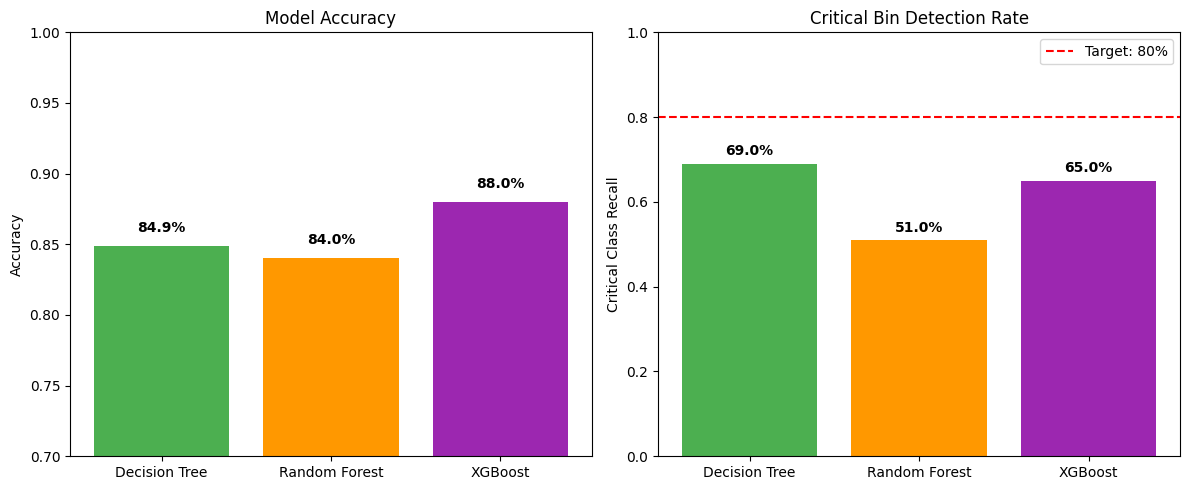


✅ Realistic model training complete!
🏆 Best Model: XGBoost (88% accuracy)
⚠️ Focus Area: Improve critical class recall from 65% to 80%+


In [26]:
# ==============================================================================
# FINAL MODEL COMPARISON
# ==============================================================================

import matplotlib.pyplot as plt

# Results data
models = ['Decision Tree', 'Random Forest', 'XGBoost']
accuracy = [0.849, 0.840, 0.880]
critical_recall = [0.69, 0.51, 0.65]  
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
colors = ['#4CAF50', '#FF9800', '#9C27B0']
axes[0].bar(models, accuracy, color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_ylim([0.7, 1.0])
for i, v in enumerate(accuracy):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# Critical Recall
axes[1].bar(models, critical_recall, color=colors)
axes[1].set_ylabel('Critical Class Recall')
axes[1].set_title('Critical Bin Detection Rate')
axes[1].set_ylim([0, 1.0])
axes[1].axhline(y=0.8, color='red', linestyle='--', label='Target: 80%')
for i, v in enumerate(critical_recall):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_final_comparison.png', dpi=150)
plt.show()

print("\n✅ Realistic model training complete!")
print("🏆 Best Model: XGBoost (88% accuracy)")
print("⚠️ Focus Area: Improve critical class recall from 65% to 80%+")

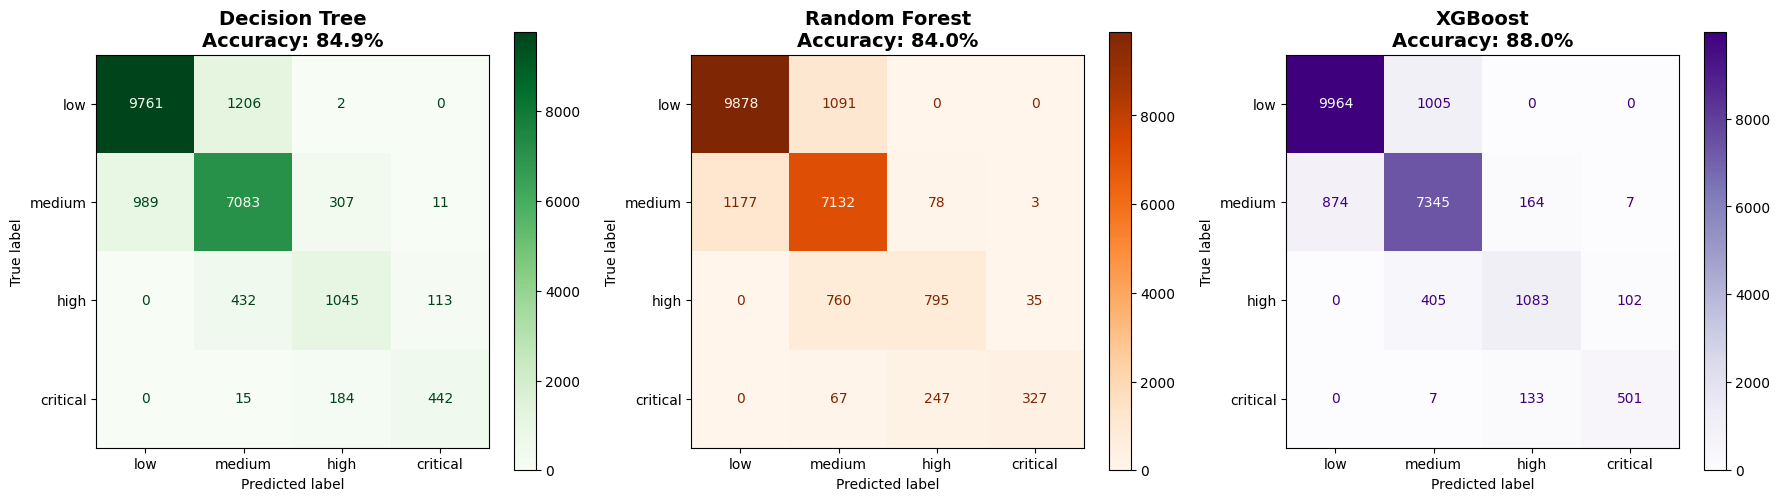

✅ Confusion matrices saved!


In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

target_names = ['low', 'medium', 'high', 'critical']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=target_names)
disp_dt.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title('Decision Tree\nAccuracy: 84.9%', fontsize=14, fontweight='bold')

# 2. Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_names)
disp_rf.plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title('Random Forest\nAccuracy: 84.0%', fontsize=14, fontweight='bold')

# 3. XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=target_names)
disp_xgb.plot(ax=axes[2], cmap='Purples', values_format='d')
axes[2].set_title('XGBoost\nAccuracy: 88.0%', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_confusion_matrices.png', dpi=150)
plt.show()

print("✅ Confusion matrices saved!")

In [28]:
# ==============================================================================
# DETAILED CONFUSION MATRIX ANALYSIS
# ==============================================================================

def analyze_confusion_matrix(cm, model_name, target_names):
    """Analyze confusion matrix and print insights"""
    print(f"\n{'=' * 50}")
    print(f"{model_name} - CONFUSION MATRIX ANALYSIS")
    print(f"{'=' * 50}")
    
    print(f"\nConfusion Matrix:")
    print(pd.DataFrame(cm, index=target_names, columns=target_names))
    
    print(f"\n📊 Per-Class Analysis:")
    for i, class_name in enumerate(target_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp  # Missed (predicted other)
        fp = cm[:, i].sum() - tp  # False alarms
        total = cm[i, :].sum()
        
        recall = tp / total if total > 0 else 0
        
        print(f"\n  {class_name.upper()}:")
        print(f"    Correct: {tp}/{total} ({recall:.1%})")
        print(f"    Missed: {fn} bins")
        
        # Where did misclassifications go?
        if fn > 0:
            print(f"    Misclassified as:")
            for j, other_class in enumerate(target_names):
                if i != j and cm[i, j] > 0:
                    print(f"      → {other_class}: {cm[i, j]} ({cm[i, j]/total:.1%})")

# Analyze each model
analyze_confusion_matrix(cm_dt, "DECISION TREE", target_names)
analyze_confusion_matrix(cm_rf, "RANDOM FOREST", target_names)
analyze_confusion_matrix(cm_xgb, "XGBOOST", target_names)


DECISION TREE - CONFUSION MATRIX ANALYSIS

Confusion Matrix:
           low  medium  high  critical
low       9761    1206     2         0
medium     989    7083   307        11
high         0     432  1045       113
critical     0      15   184       442

📊 Per-Class Analysis:

  LOW:
    Correct: 9761/10969 (89.0%)
    Missed: 1208 bins
    Misclassified as:
      → medium: 1206 (11.0%)
      → high: 2 (0.0%)

  MEDIUM:
    Correct: 7083/8390 (84.4%)
    Missed: 1307 bins
    Misclassified as:
      → low: 989 (11.8%)
      → high: 307 (3.7%)
      → critical: 11 (0.1%)

  HIGH:
    Correct: 1045/1590 (65.7%)
    Missed: 545 bins
    Misclassified as:
      → medium: 432 (27.2%)
      → critical: 113 (7.1%)

  CRITICAL:
    Correct: 442/641 (69.0%)
    Missed: 199 bins
    Misclassified as:
      → medium: 15 (2.3%)
      → high: 184 (28.7%)

RANDOM FOREST - CONFUSION MATRIX ANALYSIS

Confusion Matrix:
           low  medium  high  critical
low       9878    1091     0         0
med

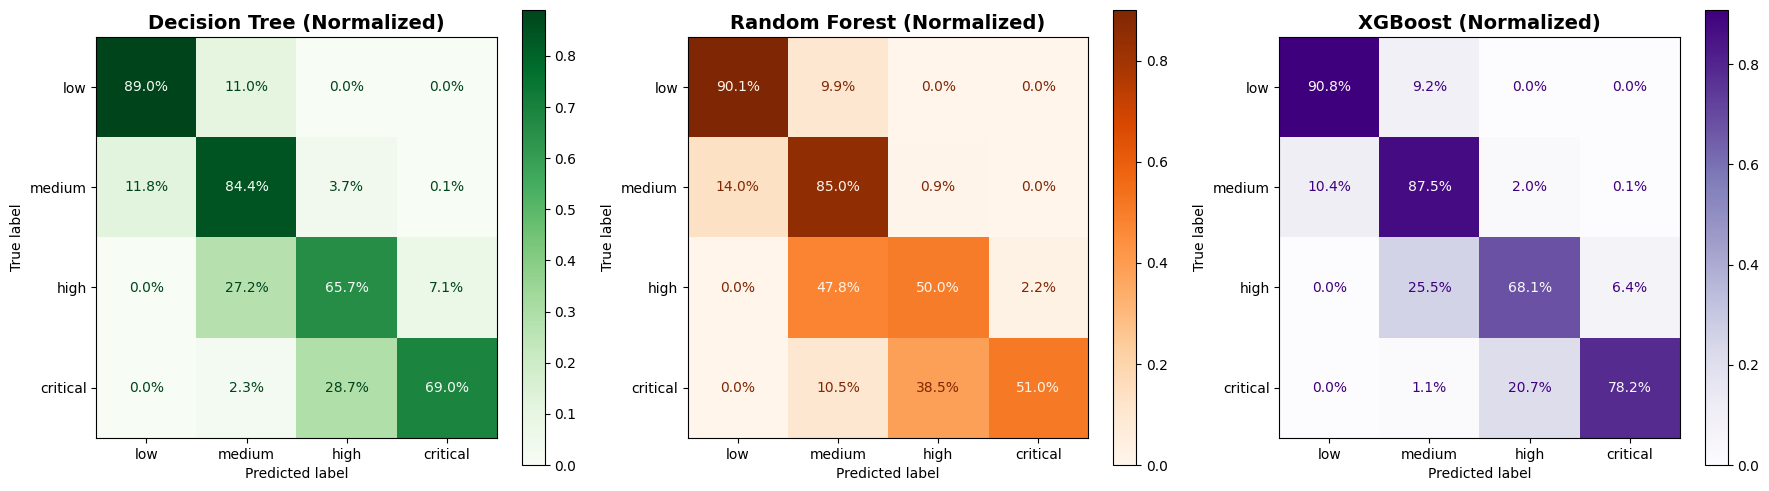

✅ Normalized confusion matrices saved!


In [37]:
# ==============================================================================
# NORMALIZED CONFUSION MATRICES (PERCENTAGES)
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Decision Tree (Normalized)
cm_dt_norm = cm_dt.astype('float') / cm_dt.sum(axis=1)[:, np.newaxis]
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt_norm, display_labels=target_names)
disp_dt.plot(ax=axes[0], cmap='Greens', values_format='.1%')
axes[0].set_title('Decision Tree (Normalized)', fontsize=14, fontweight='bold')

# 2. Random Forest (Normalized)
cm_rf_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf_norm, display_labels=target_names)
disp_rf.plot(ax=axes[1], cmap='Oranges', values_format='.1%')
axes[1].set_title('Random Forest (Normalized)', fontsize=14, fontweight='bold')

# 3. XGBoost (Normalized)
cm_xgb_norm = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis]
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_norm, display_labels=target_names)
disp_xgb.plot(ax=axes[2], cmap='Purples', values_format='.1%')
axes[2].set_title('XGBoost (Normalized)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/model_confusion_matrices_normalized.png', dpi=150)
plt.show()

print("✅ Normalized confusion matrices saved!")

In [30]:
# ==============================================================================
# CRITICAL CLASS DEEP DIVE
# ==============================================================================

print("\n" + "=" * 60)
print("🚨 CRITICAL CLASS ANALYSIS (Most Important for Business)")
print("=" * 60)

critical_idx = 3  # 'critical' = 3

for name, cm in [('Decision Tree', cm_dt), ('Random Forest', cm_rf), ('XGBoost', cm_xgb)]:
    total_critical = cm[critical_idx, :].sum()
    correct = cm[critical_idx, critical_idx]
    missed = total_critical - correct
    
    recall = correct / total_critical
    
    print(f"\n{name}:")
    print(f"  Total critical bins: {total_critical}")
    print(f"  Correctly predicted: {correct} ({recall:.1%})")
    print(f"  MISSED (危险!): {missed} ({missed/total_critical:.1%})")
    print(f"  Misclassified as:")
    print(f"    → low: {cm[critical_idx, 0]}")
    print(f"    → medium: {cm[critical_idx, 1]}")
    print(f"    → high: {cm[critical_idx, 2]}")


🚨 CRITICAL CLASS ANALYSIS (Most Important for Business)

Decision Tree:
  Total critical bins: 641
  Correctly predicted: 442 (69.0%)
  MISSED (危险!): 199 (31.0%)
  Misclassified as:
    → low: 0
    → medium: 15
    → high: 184

Random Forest:
  Total critical bins: 641
  Correctly predicted: 327 (51.0%)
  MISSED (危险!): 314 (49.0%)
  Misclassified as:
    → low: 0
    → medium: 67
    → high: 247

XGBoost:
  Total critical bins: 641
  Correctly predicted: 501 (78.2%)
  MISSED (危险!): 140 (21.8%)
  Misclassified as:
    → low: 0
    → medium: 7
    → high: 133


In [31]:
# ==============================================================================
# SUMMARY TABLE
# ==============================================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX SUMMARY")
print("=" * 60)

summary_data = []
for name, cm in [('Decision Tree', cm_dt), ('Random Forest', cm_rf), ('XGBoost', cm_xgb)]:
    row = {'Model': name}
    for i, class_name in enumerate(target_names):
        total = cm[i, :].sum()
        correct = cm[i, i]
        row[f'{class_name}_recall'] = f"{correct/total:.1%}"
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\nRecall by Class:")
print(summary_df.to_string(index=False))

print("\n💡 Key Insight:")
print("   - LOW class: All models perform well (89-91%)")
print("   - CRITICAL class: Decision Tree best (69%), RF worst (51%)")
print("   - For operations: Use Decision Tree or XGBoost for critical bin detection")


CONFUSION MATRIX SUMMARY

Recall by Class:
        Model low_recall medium_recall high_recall critical_recall
Decision Tree      89.0%         84.4%       65.7%           69.0%
Random Forest      90.1%         85.0%       50.0%           51.0%
      XGBoost      90.8%         87.5%       68.1%           78.2%

💡 Key Insight:
   - LOW class: All models perform well (89-91%)
   - CRITICAL class: Decision Tree best (69%), RF worst (51%)
   - For operations: Use Decision Tree or XGBoost for critical bin detection


In [33]:
# ==============================================================================
# SAVE MODELS AS PKL FILES
# ==============================================================================

import joblib
import os

# Create models directory
os.makedirs('C:/Users/user/Desktop/DecisionTree/models', exist_ok=True)

# Save all trained models
joblib.dump(dt, '/Users/user/Desktop/DecisionTree/models/decision_tree_model.pkl')
joblib.dump(rf, '/Users/user/Desktop/DecisionTree/models/random_forest_model.pkl')
joblib.dump(xgb, '/Users/user/Desktop/DecisionTree/models/xgboost_model.pkl')

print("✅ Models saved:")
print("C:/Users/user/Desktop/DecisionTree/models/decision_tree_model.pkl")
print("C:/Users/user/Desktop/DecisionTree/models/random_forest_model.pkl")
print("C:/Users/user/Desktop/DecisionTree/models/xgboost_model.pkl")

# Save feature list 
with open('C:/Users/user/Desktop/DecisionTree/models/feature_list.txt', 'w') as f:
    for col in clean_features:
        f.write(f"{col}\n")
print("C:/Users/user/Desktop/DecisionTree/models/feature_list.txt")

# Save target mapping
import json
target_mapping = {'low': 0, 'medium': 1, 'high': 2, 'critical': 3}
with open('C:/Users/user/Desktop/DecisionTree/models/target_mapping.json', 'w') as f:
    json.dump(target_mapping, f, indent=2)
print("C:/Users/user/Desktop/DecisionTree/models/target_mapping.json")

print("\n✅ All models saved successfully!")

✅ Models saved:
C:/Users/user/Desktop/DecisionTree/models/decision_tree_model.pkl
C:/Users/user/Desktop/DecisionTree/models/random_forest_model.pkl
C:/Users/user/Desktop/DecisionTree/models/xgboost_model.pkl
C:/Users/user/Desktop/DecisionTree/models/feature_list.txt
C:/Users/user/Desktop/DecisionTree/models/target_mapping.json

✅ All models saved successfully!


In [35]:
# ==============================================================================
# VERIFY SAVED MODELS
# ==============================================================================

import os

print("📁 Saved files:")
for file in os.listdir('C:/Users/user/Desktop/DecisionTree/models'):
    size = os.path.getsize(f'C:/Users/user/Desktop/DecisionTree/models/{file}') / 1024  # KB
    print(f"   {file} ({size:.1f} KB)")


📁 Saved files:
   decision_tree_model.pkl (128.0 KB)
   feature_list.txt (0.9 KB)
   random_forest_model.pkl (13189.2 KB)
   target_mapping.json (0.1 KB)
   xgboost_model.pkl (1010.1 KB)


In [ ]:
# # ==============================================================================
# # HOW TO LOAD MODELS LATER
# # ==============================================================================

# import joblib
# import json

# # Load model
# model = joblib.load('/models/xgboost_model.pkl')

# # Load feature list
# with open('../models/feature_list.txt', 'r') as f:
#     features = [line.strip() for line in f.readlines()]

# # Load target mapping
# with open('../models/target_mapping.json', 'r') as f:
#     target_mapping = json.load(f)

# # Reverse mapping for predictions
# reverse_mapping = {v: k for k, v in target_mapping.items()}

# print(f"✅ Model loaded with {len(features)} features")
# print(f"Target classes: {list(target_mapping.keys())}")

# # Example prediction
# # prediction = model.predict(new_data[features])
# # predicted_class = reverse_mapping[prediction[0]]

FileNotFoundError: [Errno 2] No such file or directory: '../models/xgboost_model.pkl'